In [1]:
import pandas as pd

# Load the datasets
df_chargeable = pd.read_csv('chargeable-income-of-companies.csv')
df_tax_group = pd.read_csv('chargeable-income-of-companies-by-tax-group.csv')
df_income_type = pd.read_csv('income-of-companies-by-income-type.csv')
df_group_income_type = pd.read_csv('income-of-companies-by-tax-group-and-income-type.csv')

# Inspect the columns and first few rows
print("Chargeable Income Columns:", df_chargeable.columns)
print(df_chargeable.head())

print("\nTax Group Columns:", df_tax_group.columns)
print(df_tax_group.head())

print("\nIncome Type Columns:", df_income_type.columns)
print(df_income_type.head())

print("\nGroup Income Type Columns:", df_group_income_type.columns)
print(df_group_income_type.head())

Chargeable Income Columns: Index(['year_of_assessment', 'no_of_companies_assessed', 'total_income',
       'donations', 'chargeable_income', 'group_relief',
       'loss_carryback_relief', 'ci_aft_reliefs', 'tax_exemption',
       'ci_aft_exemption', 'gross_tax_payable', 'tax_deducted_at_source',
       'other_tax_set_offs', 'net_tax_assessed'],
      dtype='str')
   year_of_assessment  no_of_companies_assessed  total_income  donations  \
0                2007                    123558      31852563     144932   
1                2008                    132335      41789422     304607   
2                2009                    147606      31257184     642328   
3                2010                    155790      20400799     870509   
4                2011                    161211      25895750    1205382   

   chargeable_income  group_relief  loss_carryback_relief  ci_aft_reliefs  \
0           69238304       1006121                  27100        68205083   
1           82078918  

       total_income  no_of_companies_assessed  net_tax_assessed
count  1.200000e+01                 12.000000      1.200000e+01
mean   2.817049e+07             175097.333333      1.228170e+07
std    6.837788e+06              33302.287998      1.904043e+06
min    1.986486e+07             123558.000000      9.390914e+06
25%    2.393029e+07             153744.000000      1.060330e+07
50%    2.595521e+07             172191.500000      1.277724e+07
75%    3.140603e+07             200874.500000      1.339893e+07
max    4.178942e+07             228996.000000      1.567081e+07


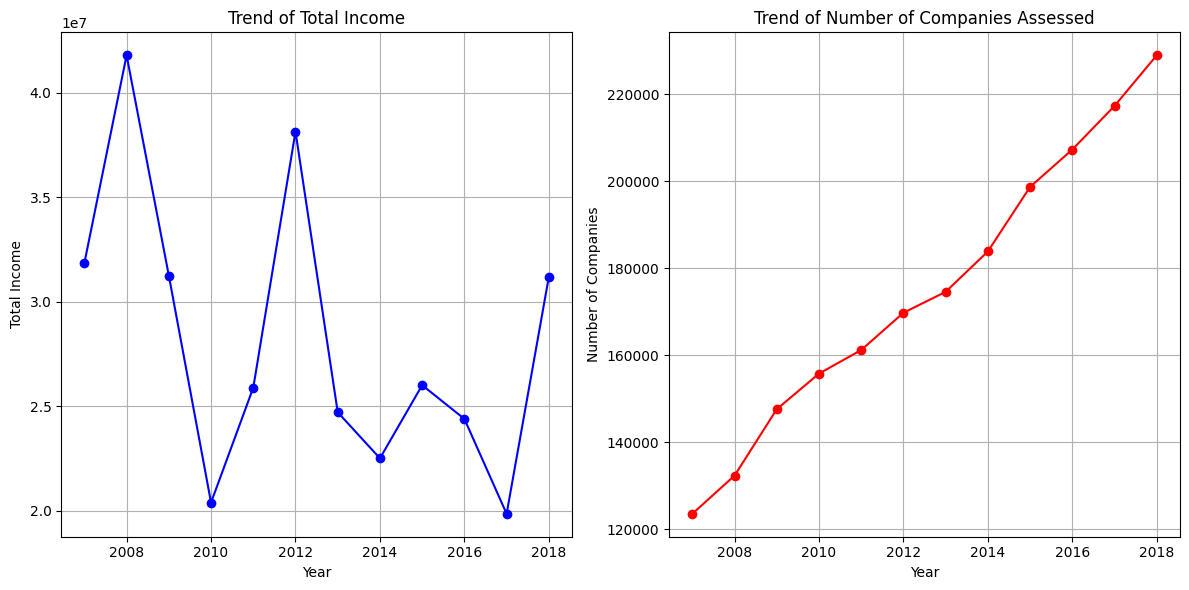

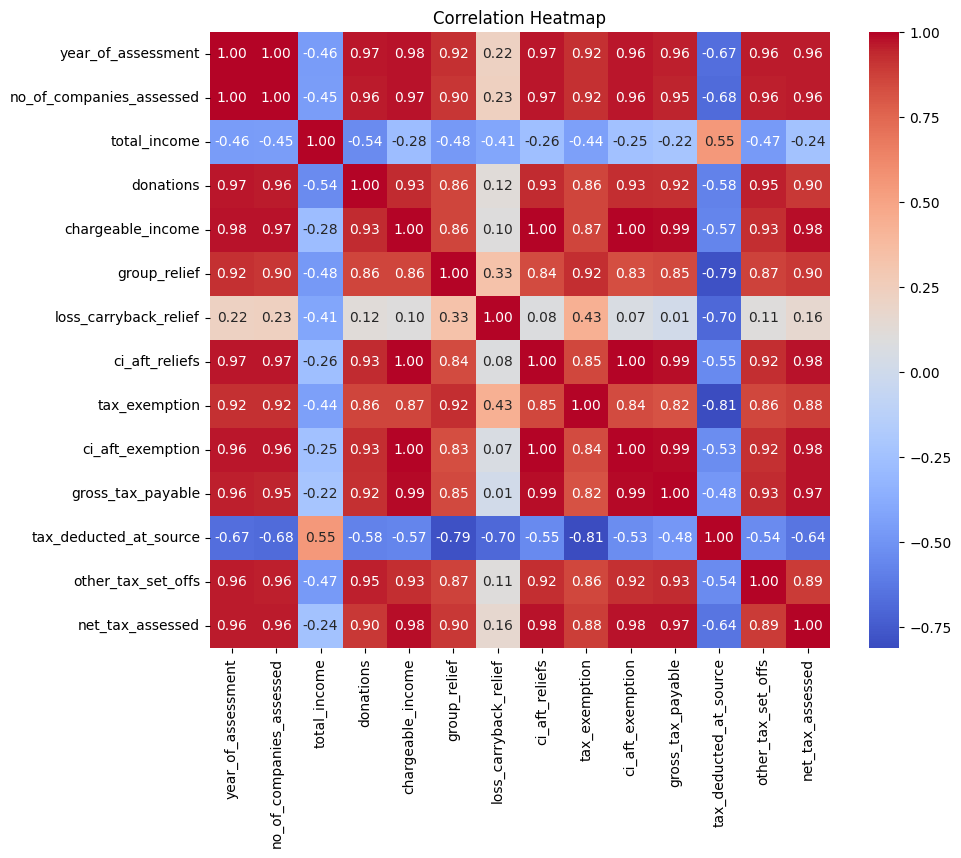

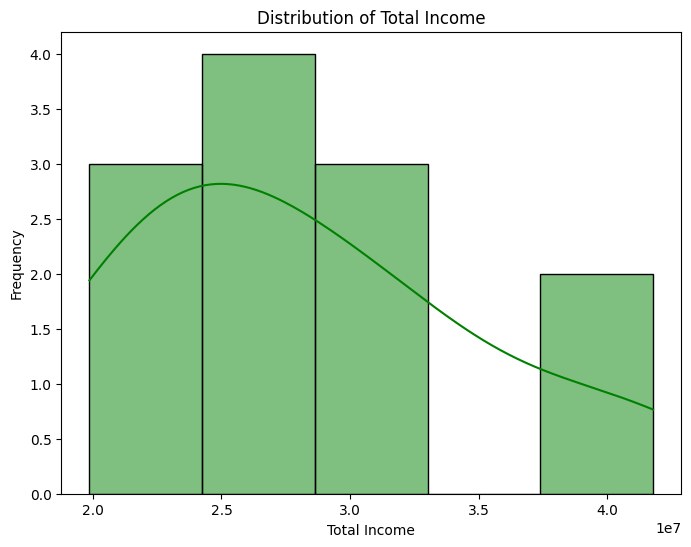

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Trend Analysis
# Columns: year_of_assessment, no_of_companies_assessed, total_income
# Let's visualize the trends over years.

plt.figure(figsize=(12, 6))

# Plot Total Income
plt.subplot(1, 2, 1)
plt.plot(df_chargeable['year_of_assessment'], df_chargeable['total_income'], marker='o', linestyle='-', color='b')
plt.title('Trend of Total Income')
plt.xlabel('Year')
plt.ylabel('Total Income')
plt.grid(True)

# Plot No of Companies Assessed
plt.subplot(1, 2, 2)
plt.plot(df_chargeable['year_of_assessment'], df_chargeable['no_of_companies_assessed'], marker='o', linestyle='-', color='r')
plt.title('Trend of Number of Companies Assessed')
plt.xlabel('Year')
plt.ylabel('Number of Companies')
plt.grid(True)

plt.tight_layout()
plt.savefig('trends.png')

# 2. Correlation Heatmap
# Select numerical columns for correlation
numerical_cols = df_chargeable.select_dtypes(include=[np.number]).columns
corr_matrix = df_chargeable[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

# 3. Return Distribution
# Interpreting "Return Distribution" as distribution of "Total Income"
plt.figure(figsize=(8, 6))
sns.histplot(df_chargeable['total_income'], kde=True, color='green')
plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Frequency')
plt.savefig('income_distribution.png')

# Prepare summary statistics for the user
summary_stats = df_chargeable[['total_income', 'no_of_companies_assessed', 'net_tax_assessed']].describe()
print(summary_stats)